In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings('ignore')

In [2]:
df=pd.read_csv("C:/Users/Sudha/zomato2.csv")

In [3]:
df.head(5)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,reviews_list,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,Casual Dining,800.0,A beautiful place to dine inThe interiors ta...,Buffet
1,SpiceElephant,Yes,No,4.1,787,Banashankari,Casual Dining,Casual Dining,800.0,Had been here for dinner with family Turned ...,Buffet
2,SanChurroCafe,Yes,No,3.8,918,Banashankari,others,others,800.0,Ambience is not that good enough and its not...,Buffet
3,AddhuriUdupiBhojana,No,No,3.7,88,Banashankari,Quick Bites,Quick Bites,300.0,Great food and proper Karnataka style full m...,Buffet
4,GrandVillage,No,No,3.8,166,Basavanagudi,Casual Dining,Casual Dining,600.0,Very good restaurant in neighbourhood Buffet...,Buffet


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49656 entries, 0 to 49655
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          49641 non-null  object 
 1   online_order  49656 non-null  object 
 2   book_table    49656 non-null  object 
 3   rate          49656 non-null  float64
 4   votes         49656 non-null  int64  
 5   location      49656 non-null  object 
 6   rest_type     49656 non-null  object 
 7   cuisines      49656 non-null  object 
 8   Cost2plates   49656 non-null  float64
 9   reviews_list  42118 non-null  object 
 10  Type          49656 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 4.2+ MB


In [5]:
df.describe()

,rate,votes,Cost2plates
count,49656.000000,49656.000000,49656.000000
mean,3.678679,190.617952,500.572438
std,0.382428,388.366899,327.736785
min,1.800000,0.000000,0.000000
25%,3.500000,6.000000,300.000000
50%,3.700526,37.000000,400.000000
75%,3.900000,172.000000,600.000000
max,4.900000,2692.000000,1800.000000


In [6]:
df.corr(numeric_only=True)#correlation

,rate,votes,Cost2plates
rate,1.000000,0.466790,0.314086
votes,0.466790,1.000000,0.498248
Cost2plates,0.314086,0.498248,1.000000


<Figure size 400x400 with 0 Axes>

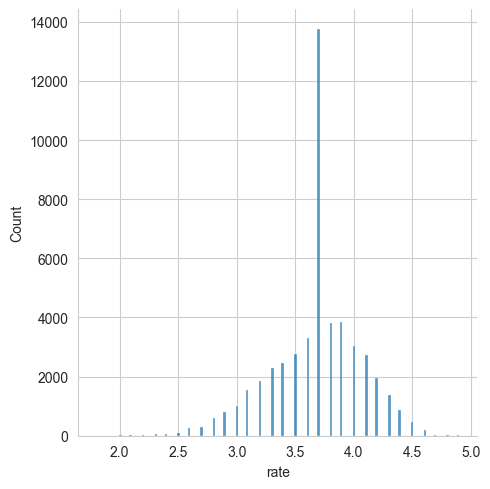

In [7]:
plt.figure(figsize=(4,4))
sns.set_style("whitegrid")
sns.displot(df['rate'])
plt.show()


Which locations has most Restuarant?

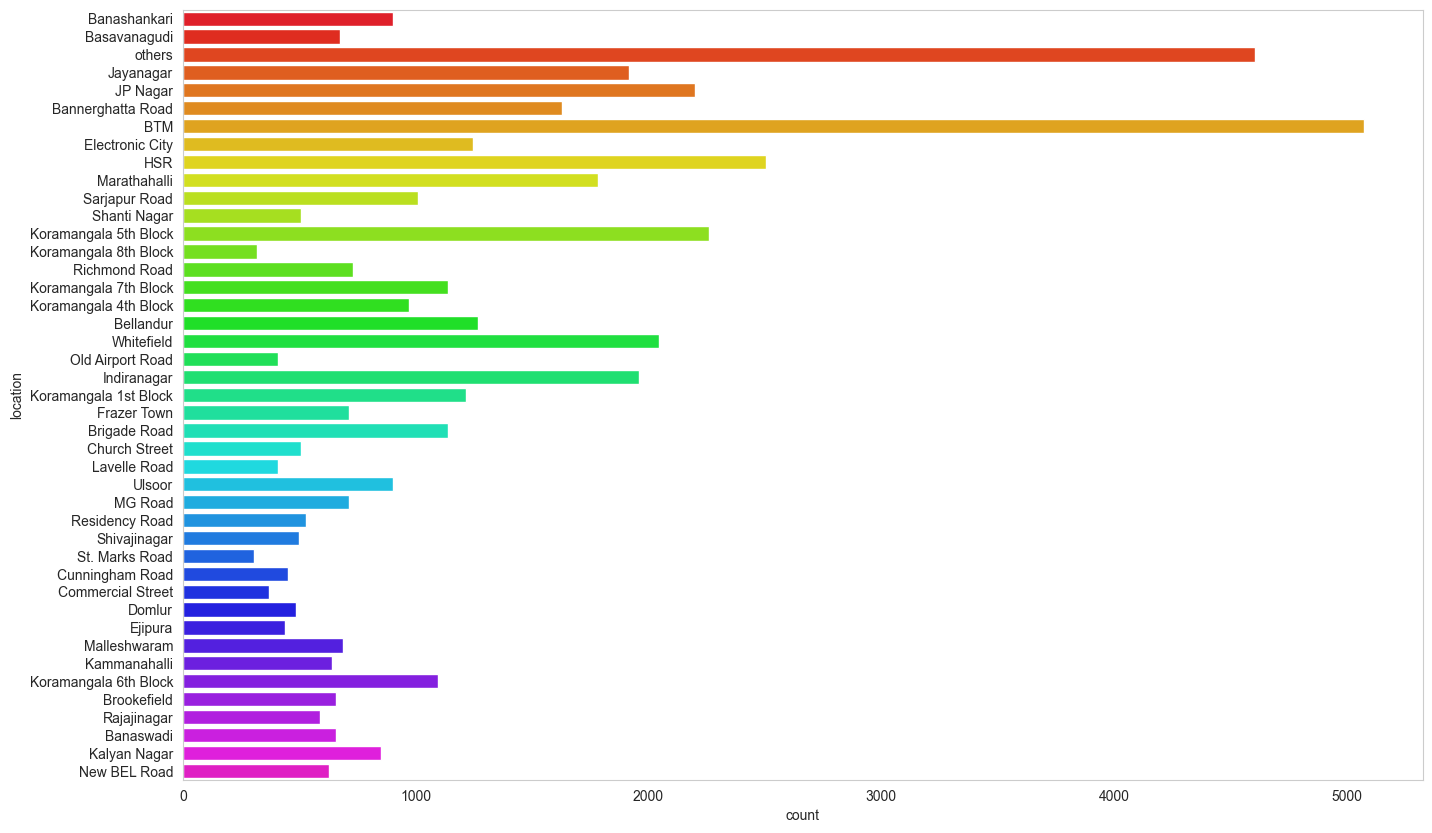

In [27]:
plt.figure(figsize = (16,10))
ax = sns.countplot(df['location'],palette="gist_rainbow")
plt.grid(False)
#plt.xticks(rotation=90)

How many Restuarant take online order?

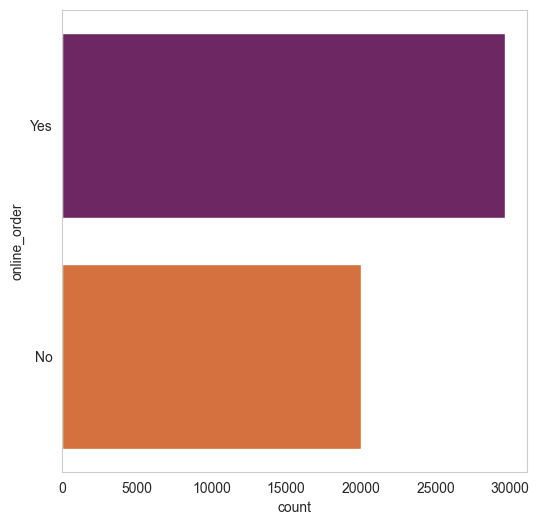

In [28]:
plt.figure(figsize = (6,6))
sns.countplot(df['online_order'], palette = 'inferno')
plt.grid(False)

How many Restuarant Have Book table Facility?

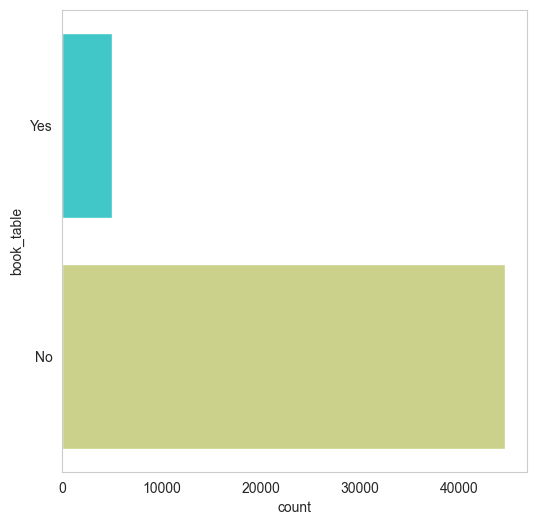

In [29]:
plt.figure(figsize = (6,6))
sns.countplot(df['book_table'], palette = 'rainbow')
plt.grid(False)

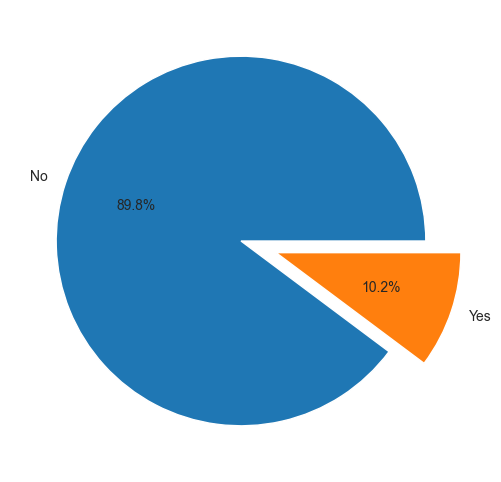

In [12]:
plt.figure(figsize = (6,6))
x=df['book_table'].value_counts()
labels=["No","Yes"]

    
plt.pie(x,labels=labels,explode=[0,0.2],autopct='%1.1f%%')
plt.show()

How much is the rate of restuarant if it has Online Order Facility?

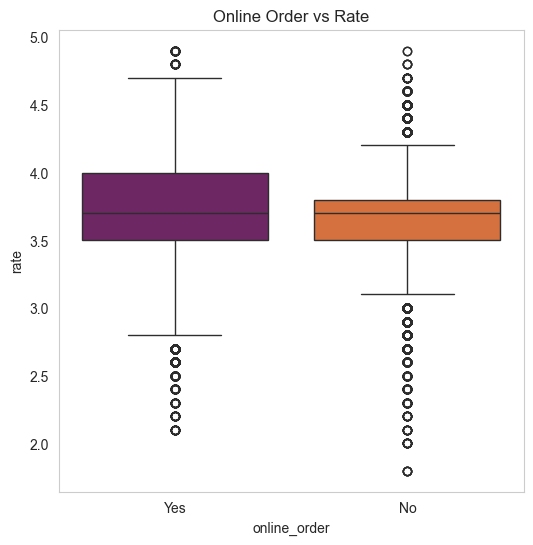

In [30]:
plt.figure(figsize = (6,6))
plt.title("Online Order vs Rate")
sns.boxplot(x = 'online_order', y = 'rate',palette="inferno",data = df)
plt.grid(False)

How much is the Rate of restuarant if its have Book_table Facility?

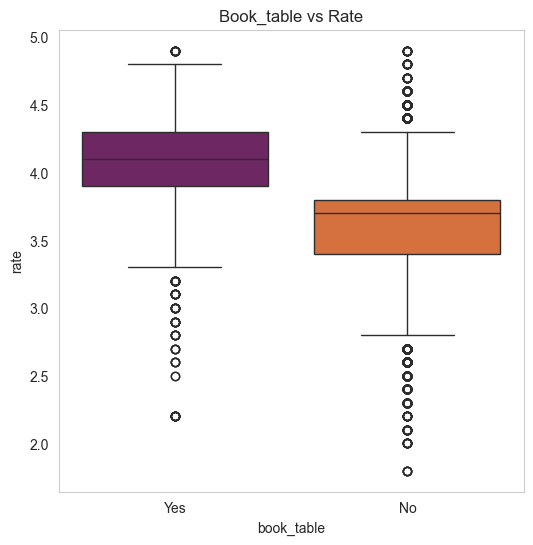

In [31]:
plt.figure(figsize = (6,6))
plt.title("Book_table vs Rate")
sns.boxplot(x = 'book_table', y = 'rate',palette="inferno",data = df)
plt.grid(False)

In which location,I can open Restuarant with online order facility?

In [15]:
df1 = df.groupby(['location','online_order'])['name'].count()
df1=pd.DataFrame(df1)
df1 = pd.pivot_table(df1, values=None, index=['location'], columns=['online_order'], fill_value=0, aggfunc=np.sum)
df1

name      
online_order             No   Yes
location                         
BTM                    1769  3303
Banashankari            395   507
Banaswadi               321   339
Bannerghatta Road       704   923
Basavanagudi            234   441
Bellandur               512   755
Brigade Road            514   626
Brookefield             241   417
Church Street           226   282
Commercial Street       228   142
Cunningham Road         162   288
Domlur                  252   235
Ejipura                 219   220
Electronic City         673   572
Frazer Town             294   422
HSR                     596  1910
Indiranagar             679  1281
JP Nagar                905  1295
Jayanagar               556  1353
Kalyan Nagar            355   496
Kammanahalli            267   375
Koramangala 1st Block   378   839
Koramangala 4th Block   431   539
Koramangala 5th Block   745  1515
Koramangala 6th Block   431   667
Koramangala 7th Block   381   759
Koramangala 8th Block   108   212
Lavelle Road            252   156
MG Road                 414   302
Malleshwaram            289   398
Marathahalli            697  1085
New BEL Road            245   382
Old Airport Road        194   216
Rajajinagar             283   305
Residency Road          302   227
Richmond Road           482   247
Sarjapur Road           311   701
Shanti Nagar            289   219
Shivajinagar            354   144
St. Marks Road          158   149
Ulsoor                  293   611
Whitefield              930  1114
others                 1928  2675

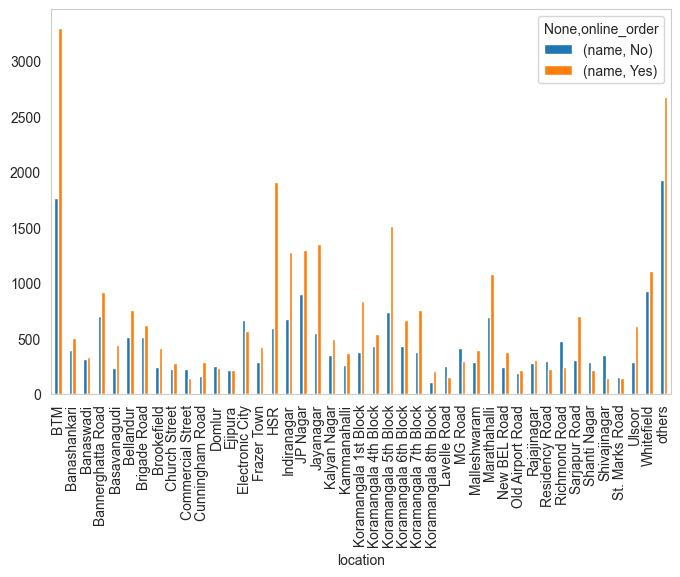

In [32]:
df1.plot(kind = 'bar', figsize = (8,5))
plt.grid(False)

In which location,I can open Restuarant with Book Table facility?

In [17]:
df2 = df.groupby(['location','book_table'])['name'].count()
df2 = pd.DataFrame(df2)
df2 = pd.pivot_table(df2, values=None, index=['location'], columns=['book_table'], fill_value=0, aggfunc=np.sum)
df2

name     
book_table               No  Yes
location                        
BTM                    4929  143
Banashankari            841   61
Banaswadi               652    8
Bannerghatta Road      1528   99
Basavanagudi            665   10
Bellandur              1182   85
Brigade Road            999  141
Brookefield             584   74
Church Street           353  155
Commercial Street       370    0
Cunningham Road         315  135
Domlur                  441   46
Ejipura                 439    0
Electronic City        1158   87
Frazer Town             713    3
HSR                    2303  203
Indiranagar            1583  377
JP Nagar               1915  285
Jayanagar              1636  273
Kalyan Nagar            704  147
Kammanahalli            593   49
Koramangala 1st Block  1174   43
Koramangala 4th Block   687  283
Koramangala 5th Block  1725  535
Koramangala 6th Block  1007   91
Koramangala 7th Block   990  150
Koramangala 8th Block   303   17
Lavelle Road            282  126
MG Road                 517  199
Malleshwaram            629   58
Marathahalli           1674  108
New BEL Road            587   40
Old Airport Road        383   27
Rajajinagar             550   38
Residency Road          483   46
Richmond Road           642   87
Sarjapur Road           909  103
Shanti Nagar            451   57
Shivajinagar            475   23
St. Marks Road          213   94
Ulsoor                  809   95
Whitefield             1840  204
others                 4349  254

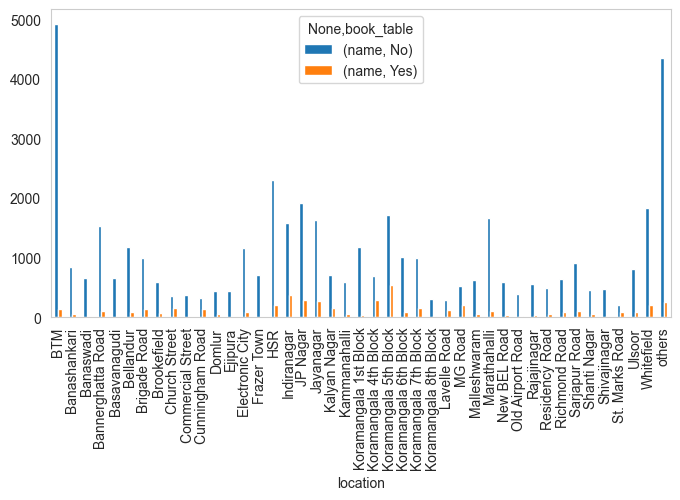

In [33]:
df2.plot(kind = 'bar', figsize = (8,4))
plt.grid(False)

Which type of Restuarant has highest Rating?

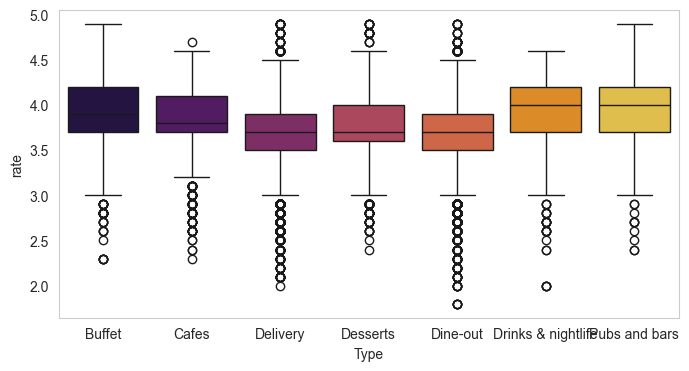

In [34]:
plt.figure(figsize = (8,4))
sns.boxplot(x = 'Type', y = 'rate', data = df, palette = 'inferno')
plt.grid(False)

In which location we get most types of restuarants?

In [40]:
df3 = df.groupby(['location','Type'])['name'].count()
df3 = pd.DataFrame(df3)
df3 = pd.pivot_table(df3, values=None, index=['location'], columns=['Type'], fill_value=0, aggfunc=np.sum)
df3

name                                   \
Type                  Buffet Cafes Delivery Desserts Dine-out   
location                                                        
BTM                       17    83     3068      202     1661   
Banashankari               7    36      418       71      356   
Banaswadi                  0    24      321       37      271   
Bannerghatta Road          8    46      842      137      583   
Basavanagudi               7    11      344       66      245   
Bellandur                 23    36      621       77      480   
Brigade Road              25    46      483      108      428   
Brookefield                6    17      340       45      246   
Church Street             10    46      170       29      194   
Commercial Street          0    13      121       77      159   
Cunningham Road           29    28      188       20      172   
Domlur                    13    17      261       35      138   
Ejipura                    0     0      251       16      172   
Electronic City           20    24      574       71      515   
Frazer Town                1    11      471       56      173   
HSR                       17    48     1711      122      580   
Indiranagar               29    98     1090      145      500   
JP Nagar                  41    72     1153      166      716   
Jayanagar                 23    77     1042      182      573   
Kalyan Nagar               9    45      370       88      322   
Kammanahalli               1    27      330       35      243   
Koramangala 1st Block      0    22      712       70      390   
Koramangala 4th Block     17    45      460       78      286   
Koramangala 5th Block     40   131     1020      210      765   
Koramangala 6th Block     14    43      512       66      403   
Koramangala 7th Block     25    52      497      127      402   
Koramangala 8th Block      0    10      213       28       67   
Lavelle Road              25    27      108       50      134   
MG Road                   22    69      244       73      242   
Malleshwaram               8    31      262       85      275   
Marathahalli              26    31      983      106      618   
New BEL Road               4    26      336       33      219   
Old Airport Road           6     5      202       37      147   
Rajajinagar                9     4      257       55      250   
Residency Road             5    26      182       53      210   
Richmond Road             49    25      258       78      315   
Sarjapur Road             19    23      556       83      308   
Shanti Nagar               9    22      198       39      229   
Shivajinagar               6    17      143       37      280   
St. Marks Road             5     5      105       10      135   
Ulsoor                     5    49      457       59      292   
Whitefield                21    49     1051      139      727   
others                    73   118     2616      253     1453   

                                                        
Type                  Drinks & nightlife Pubs and bars  
location                                                
BTM                                   22            19  
Banashankari                          14             0  
Banaswadi                              6             1  
Bannerghatta Road                      9             2  
Basavanagudi                           2             0  
Bellandur                             14            16  
Brigade Road                          37            13  
Brookefield                            4             0  
Church Street                         36            23  
Commercial Street                      0             0  
Cunningham Road                       10             3  
Domlur                                12            11  
Ejipura                                0             0  
Electronic City                       20            21  
Frazer Town                            2             2  
HSR    

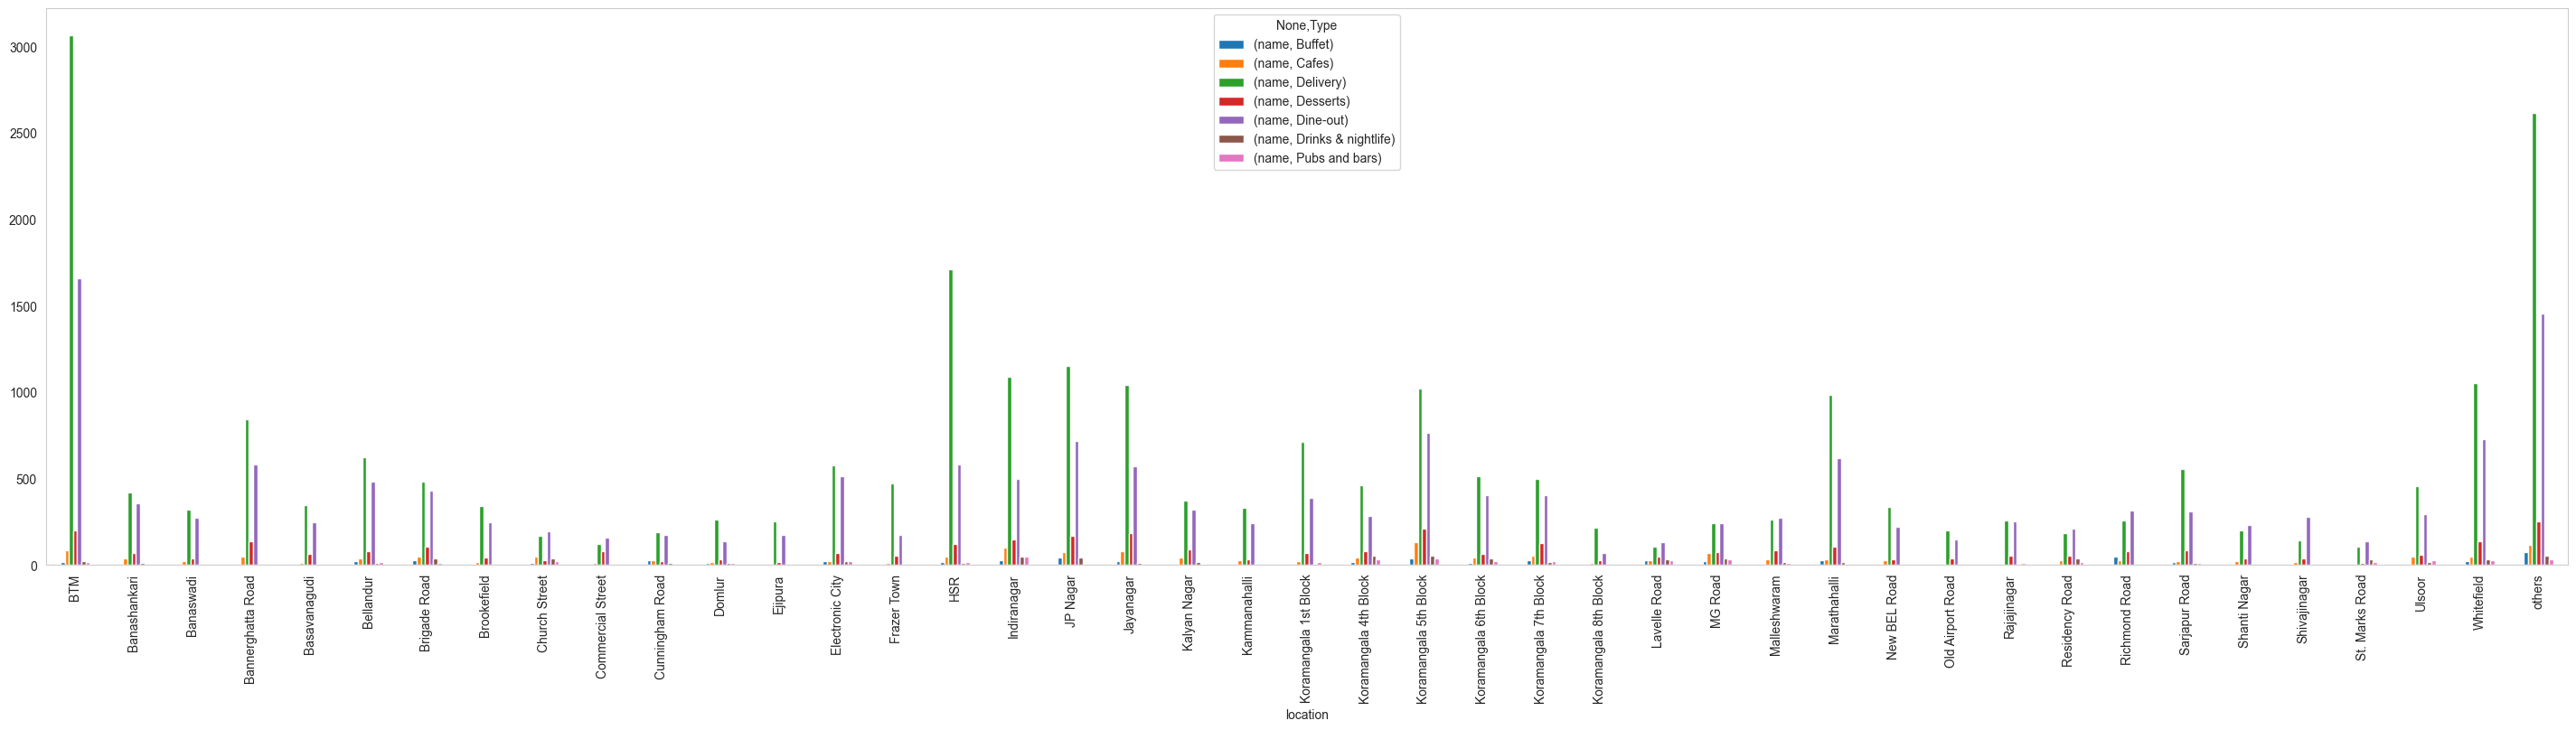

In [35]:
df3.plot(kind = 'bar', figsize = (36,8))
plt.grid(False)

In which location,Restuarents have highest votes?

In [22]:
df4 = df[['location', 'votes']]
df4.drop_duplicates()
df5 = df4.groupby(['location'])['votes'].sum()
df5 = df5.to_frame()
df5 = df5.sort_values('votes', ascending=False)
df5.head()

,votes
location,
Koramangala 5th Block,1068914
Indiranagar,716721
BTM,483654
others,459859
JP Nagar,448823


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42],
 [Text(0, 0, 'Koramangala 5th Block'),
  Text(1, 0, 'Indiranagar'),
  Text(2, 0, 'BTM'),
  Text(3, 0, 'others'),
  Text(4, 0, 'JP Nagar'),
  Text(5, 0, 'Jayanagar'),
  Text(6, 0, 'HSR'),
  Text(7, 0, 'Koramangala 6th Block'),
  Text(8, 0, 'Koramangala 4th Block'),
  Text(9, 0, 'Church Street'),
  Text(10, 0, 'Whitefield'),
  Text(11, 0, 'Koramangala 7th Block'),
  Text(12, 0, 'Lavelle Road'),
  Text(13, 0, 'Marathahalli'),
  Text(14, 0, 'Brigade Road'),
  Text(15, 0, 'Bannerghatta Road'),
  Text(16, 0, 'MG Road'),
  Text(17, 0, 'Koramangala 1st Block'),
  Text(18, 0, 'Bellandur'),
  Text(19, 0, 'Kalyan Nagar'),
  Text(20, 0, 'Banashankari'),
  Text(21, 0, 'Ulsoor'),
  Text(22, 0, 'Residency Road'),
  Text(23, 0, 'Sarjapur Road'),
  Text(24, 

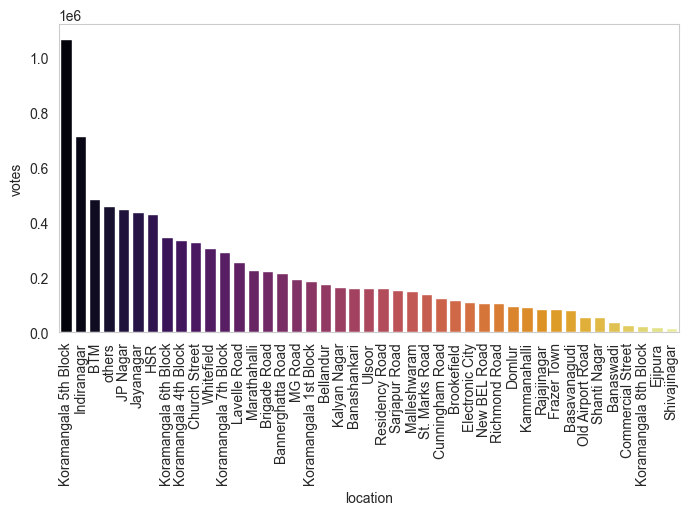

In [38]:
plt.figure(figsize = (8,4))
plt.grid(False)
sns.barplot(x=df5.index ,y=df5['votes'],palette='inferno')
plt.xticks(rotation = 90)


On the Basis of Votes,Which Cuisines Restuarant i should Open?

In [41]:
df6 = df[['cuisines', 'votes']]
df6.drop_duplicates(inplace=True)
df7 = df6.groupby(['cuisines'])['votes'].sum()
df7 = df7.to_frame()
df7 = df7.sort_values('votes', ascending=False)
df7.head()

,votes
cuisines,
Casual Dining,1099090
others,781655
Cafe,354777
Quick Bites,311060
"Casual Dining, Bar",291216


In [25]:
df7 = df7.iloc[1:, :]
df7.head()

,votes
cuisines,
others,781655
Cafe,354777
Quick Bites,311060
"Casual Dining, Bar",291216
Dessert Parlor,127373


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'others'),
  Text(1, 0, 'Cafe'),
  Text(2, 0, 'Quick Bites'),
  Text(3, 0, 'Casual Dining, Bar'),
  Text(4, 0, 'Dessert Parlor'),
  Text(5, 0, 'Delivery'),
  Text(6, 0, 'Takeaway, Delivery'),
  Text(7, 0, 'Bakery')])

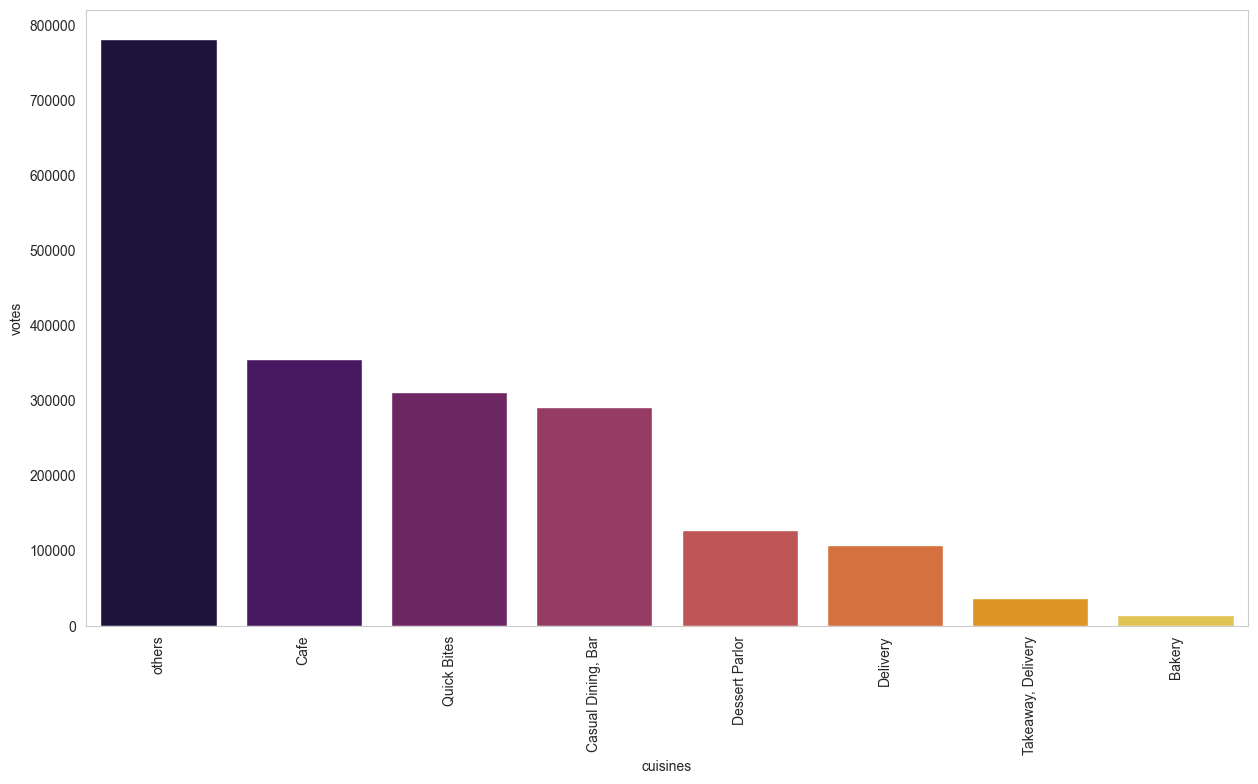

In [39]:
plt.figure(figsize = (15,8))
plt.grid(False)
sns.barplot(x=df7.index ,y=df7['votes'],palette='inferno')
plt.xticks(rotation = 90)